# importing libraries 

In [97]:
import pandas as pd
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report

# importing data

In [98]:
import pandas as pd

# Read the data
df = pd.read_excel('go_emotions_v2.xlsx')


print(df['emotion'].value_counts())

emotion
happiness    16405
neutral      15138
anger         5336
sadness       4123
surprise      3289
disgust       2445
fear          2176
Name: count, dtype: int64


here i import the test data that we got from the client testline. We use this data to evaluate the performance of our model

In [99]:
filepath_2 = os.path.join(os.path.dirname(os.getcwd()), "data/group_4_url_1_transcript.csv")
df_test = pd.read_csv(filepath_2)
df_test = df_test.sample(n=len(df_test))

In [100]:
df_train = df

In [101]:
df_train.shape

(48912, 2)

In [102]:
df_train.head()

,text,emotion
0,My favourite food is anything I didn't have to...,neutral
1,"Now if he does off himself, everyone will thin...",neutral
2,WHY THE FUCK IS BAYLESS ISOING,anger
3,To make her feel threatened,fear
4,Dirty Southern Wankers,anger


In [107]:
df_train = df_train.dropna(subset=['text'])

# training model

or the TF-IDF vectorization, we took the top 100000 most frequent words. after some tests we found this to give the best results. We used ngram_range of (1,2) to capture both single words and word pairs like "not happy", which is important for emotion detection. We filtered out super rare words that appear in less than 2 documents with min_df=2, and we removed extremely common words that appear in more than 95% of documents using max_df=0.95 - these are usually words like "the" or "and" that don't help with classification. We applied log scaling with sublinear_tf=True so that words appearing 100 times aren't treated as 100 times more important than words appearing once. Finally, we normalized everything to unit vectors using L2 norm.

For the model, we chose LinearSVC which is fast and effective for text classification. We set class_weight='balanced' to automatically compensate for our imbalanced dataset where we have way more happiness samples than disgust samples. We used C=0.1 for regularization - this low value means more regularization which helps prevent overfitting. We also used squared_hinge loss which is more robust against outliers in our data.

In the testing phase, there's actually an inconsistency - we trained on df_train['text'] but we're testing on df_test['Translation'] and evaluating against df_test['Emotion_core']. We should probably make these column names consistent.

For evaluation, we calculated all the important metrics using average='weighted' which gives us a better picture for imbalanced datasets. The classification report at the end shows us how well we're doing for each individual emotion class. This is a solid approach for emotion classification, especially with those well-tuned TF-IDF parameters.

In [108]:
# Train on df_train
vectorizer = TfidfVectorizer(
    max_features=100000,        # Keep top N most frequent words
    ngram_range=(1, 2),       # (1,1) = unigrams, (1,2) = uni+bigrams
    min_df=2,                 # Ignore words appearing in < 2 documents
    max_df=0.95,              # Ignore words appearing in > 95% of docs
    sublinear_tf=True,        # Apply log scaling to term frequency
    use_idf=True,             # Use inverse document frequency
    norm='l2'                 # Normalize vectors to unit length
)
X_train_tfidf = vectorizer.fit_transform(df_train['text'])
model = LinearSVC(class_weight='balanced', max_iter=1000, C=0.1, loss='squared_hinge').fit(X_train_tfidf, df_train['emotion'])


# Test on df_test
X_test_tfidf = vectorizer.transform(df_test['Translation'])
predictions = model.predict(X_test_tfidf)

# Calculate metrics
accuracy = accuracy_score(df_test['Emotion_core'], predictions)
precision = precision_score(df_test['Emotion_core'], predictions, average='weighted')
recall = recall_score(df_test['Emotion_core'], predictions, average='weighted')
f1 = f1_score(df_test['Emotion_core'], predictions, average='weighted')

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print(classification_report(df_test['Emotion_core'], predictions))

Accuracy:  0.547
Precision: 0.528
Recall:    0.547
F1-score:  0.518
              precision    recall  f1-score   support

       anger       0.16      0.30      0.21        37
     disgust       0.10      0.24      0.14        17
        fear       0.14      0.05      0.08        56
   happiness       0.55      0.51      0.53       198
     neutral       0.64      0.79      0.71       546
     sadness       0.48      0.12      0.20       104
    surprise       0.31      0.14      0.19        92

    accuracy                           0.55      1050
   macro avg       0.34      0.31      0.29      1050
weighted avg       0.53      0.55      0.52      1050



# hyper parameter tuning

We did some hyper parameter tuning for our model to find the optimal ones. we used gridsearch for this

In [ ]:
# Create vectorizer with hyperparameters
vectorizer = TfidfVectorizer()

# Set up parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization strength
    'loss': ['hinge', 'squared_hinge'],  # Loss function
    'max_iter': [1000, 2000, 3000],
    'class_weight': ['balanced', None]
}

# Create base model
svm_model = LinearSVC()

# Grid search with cross-validation
X_train_tfidf = vectorizer.fit_transform(df_train['text'])
grid_search = GridSearchCV(
    svm_model, 
    param_grid, 
    cv=3,  # 3-fold cross-validation
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1  # Use all CPU cores
)

# Fit grid search
grid_search.fit(X_train_tfidf, df_train['emotion'])

# Best parameters
print("Best parameters:", grid_search.best_params_)
print(f"Best CV score: {grid_search.best_score_:.3f}")

# Test with best model
X_test_tfidf = vectorizer.transform(df_test['Translation'])
predictions = grid_search.predict(X_test_tfidf)

# Calculate metrics
accuracy = accuracy_score(df_test['Emotion_core'], predictions)
print(f"\nTest Accuracy: {accuracy:.3f}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'max_iter': 1000}
Best CV score: 0.597

Test Accuracy: 0.562


In [ ]:
df_test.head()

,Start Time,End Time,Sentence,Translation,Emotion_fine,Emotion_core,Intensity
102,1900-01-01 00:06:36,1900-01-01 00:06:38,En bij Art zou kunnen zijn.,And could be with Art.,possibility,neutral,neutral
572,1900-01-01 00:29:06.480000,1900-01-01 00:29:08.480000,Wij hebben er drie over.,We have three left.,contentment,neutral,neutral
1002,1900-01-01 00:53:26.800000,1900-01-01 00:53:29.800000,Ze dacht dat ze op de goede weg zat.,She thought she was on the right track.,hope,happiness,mild
557,1900-01-01 00:28:23.480000,1900-01-01 00:28:25.480000,Nee. Licht bij.,No. Light on.,dismissal,neutral,neutral
191,1900-01-01 00:11:12.160000,1900-01-01 00:11:14.160000,"De eerste, ja.","The first one, yes.",agreement,neutral,neutral


# error analysis

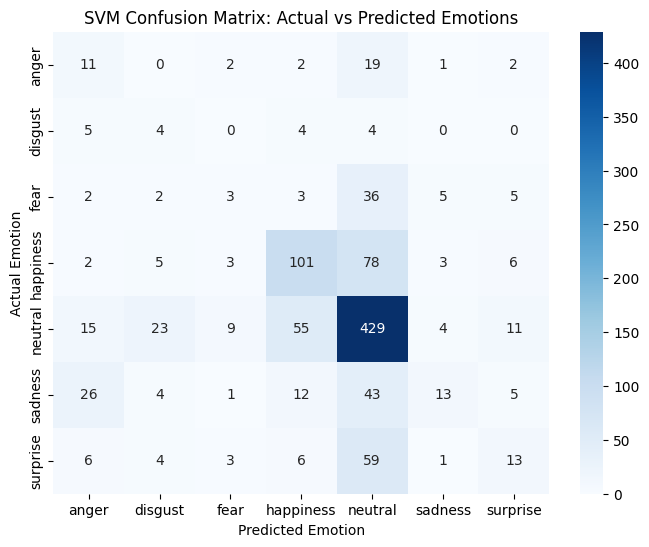


Prediction Distribution:
neutral      668
happiness    183
anger         67
surprise      42
disgust       42
sadness       27
fear          21
Name: count, dtype: int64

Actual Distribution:
Emotion_core
neutral      546
happiness    198
sadness      104
surprise      92
fear          56
anger         37
disgust       17
Name: count, dtype: int64


In [109]:
# Create confusion matrix
cm = confusion_matrix(df_test['Emotion_core'], predictions)
emotions = sorted(df_test['Emotion_core'].unique())

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotions, yticklabels=emotions)
plt.title('SVM Confusion Matrix: Actual vs Predicted Emotions')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

# Show prediction distribution
print("\nPrediction Distribution:")
print(pd.Series(predictions).value_counts())
print("\nActual Distribution:")
print(df_test['Emotion_core'].value_counts())